# RM-10 shape prior check against the H4 AIM-120A effective CdA model

## TL;DR

On the common `M1.5–2.5` interval, a constant scaling of RM-10 is not enough. The anchored shape fit gives `beta = 1.669`, reducing relative RMSE from `8.31%` to `1.76%`. RM-10 is therefore useful as a **Mach-shape prior**, but not as an absolute AIM-120 drag model. The candidate extension uses RM-10 only below `M1.2`; every existing H4 knot remains unchanged.

## Context and methods

Source: NACA Report 1160, Figure 13, body with four fins at `alpha=0°`. The plotted total-drag coefficient uses maximum body cross-sectional area. A representative composite was manually digitized from a 400 dpi scan: the center of the 146.5-inch flight-model envelope through `M1.5`, joined there to the 8×6-foot wind-tunnel centerline through `M2.5`. The report itself notes agreement of those larger-model datasets near `M1.5`.

This is not an AIM-120 geometry match. The comparison removes absolute scale and fits only the normalized Mach dependence:

`CdA_fit(M) = CdA_H4(1.5) × [Cd_RM10(M) / Cd_RM10(1.5)]^beta`

The H4 curve is evaluated with its native log-linear interpolation. The fit is anchored exactly at `M1.5` and uses only `M1.5–2.5`.

In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'outputs' / 'h4_glide_drag' / 'cda_knots_fit.json').exists()
RM10_CSV = PROJECT_ROOT / 'data' / 'reference_external' / 'rm10' / 'rm10_figure13_composite_digitization.csv'
H4_JSON = PROJECT_ROOT / 'outputs' / 'h4_glide_drag' / 'cda_knots_fit.json'
pd.read_csv(RM10_CSV).head()

,mach,cd_total,cd_uncertainty_approx,series_component,source_page,source_figure,digitization_method
0,0.90,0.166,0.006,146.5_in_flight_envelope_center,120,13,manual_from_400_dpi_scan
1,0.95,0.178,0.008,146.5_in_flight_envelope_center,120,13,manual_from_400_dpi_scan
2,1.00,0.235,0.010,146.5_in_flight_envelope_center,120,13,manual_from_400_dpi_scan
3,1.05,0.257,0.008,146.5_in_flight_envelope_center,120,13,manual_from_400_dpi_scan
4,1.10,0.262,0.008,146.5_in_flight_envelope_center,120,13,manual_from_400_dpi_scan


## Data and reproducible fit

The next cell reruns the complete fit and rewrites the JSON, CSV, and PNG outputs. Digitization uncertainty is an approximate scan-reading allowance, not a statistical measurement error.

In [2]:
runpy.run_path(str(PROJECT_ROOT / 'scripts' / 'fit_rm10_shape_prior.py'), run_name='__main__')
report = json.loads((PROJECT_ROOT / 'outputs' / 'rm10_shape_prior' / 'fit_report.json').read_text(encoding='utf-8'))
fit = report['fit']
pd.DataFrame([{
    'beta': fit['beta'],
    'beta sensitivity min': fit['beta_digitization_one_at_a_time_min'],
    'beta sensitivity max': fit['beta_digitization_one_at_a_time_max'],
    'constant-scale relative RMSE': fit['baseline_beta_1_metrics']['relative_rmse'],
    'exponent-fit relative RMSE': fit['fitted_beta_metrics']['relative_rmse'],
    'exponent-fit max relative error': fit['fitted_beta_metrics']['max_absolute_relative_error'],
}])

{
  "equation": "CdA_fit(M)=CdA_H4(1.5)*[Cd_RM10(M)/Cd_RM10(1.5)]^beta",
  "mach_range": [
    1.5,
    2.5
  ],
  "anchor_mach": 1.5,
  "h4_anchor_cda_m2": 0.019197192082694305,
  "rm10_anchor_cd": 0.253,
  "beta": 1.668993602463756,
  "beta_digitization_one_at_a_time_min": 1.5347349643763954,
  "beta_digitization_one_at_a_time_max": 1.784866980011422,
  "baseline_beta_1_metrics": {
    "relative_rmse": 0.08306011443767518,
    "relative_mae": 0.07078486908547084,
    "max_absolute_relative_error": 0.13264193134434543
  },
  "fitted_beta_metrics": {
    "relative_rmse": 0.017603597740710367,
    "relative_mae": 0.012985006624826394,
    "max_absolute_relative_error": 0.0366762824081451
  },
  "comparison_rows": [
    {
      "mach": 1.5,
      "rm10_cd_total": 0.253,
      "h4_cda_m2": 0.019197192082694305,
      "scaled_rm10_beta_1_cda_m2": 0.019197192082694305,
      "scaled_rm10_exponent_fit_cda_m2": 0.019197192082694305,
      "fit_relative_error": 0.0
    },
    {
      "mach": 1

,beta,beta sensitivity min,beta sensitivity max,constant-scale relative RMSE,exponent-fit relative RMSE,exponent-fit max relative error
0,1.668994,1.534735,1.784867,0.08306,0.017604,0.036676


## Results

,mach,rm10_cd_total,h4_cda_m2,scaled_rm10_beta_1_cda_m2,scaled_rm10_exponent_fit_cda_m2,fit_relative_error
0,1.5,0.253,0.019197,0.019197,0.019197,0.000000
1,1.6,0.251,0.018590,0.019045,0.018945,0.019091
2,1.8,0.244,0.017432,0.018514,0.018071,0.036676
3,2.0,0.232,0.016346,0.017604,0.016612,0.016297
4,2.2,0.220,0.015394,0.016693,0.015203,-0.012378
5,2.4,0.213,0.014497,0.016162,0.014404,-0.006383
6,2.5,0.210,0.014068,0.015934,0.014067,-0.000069


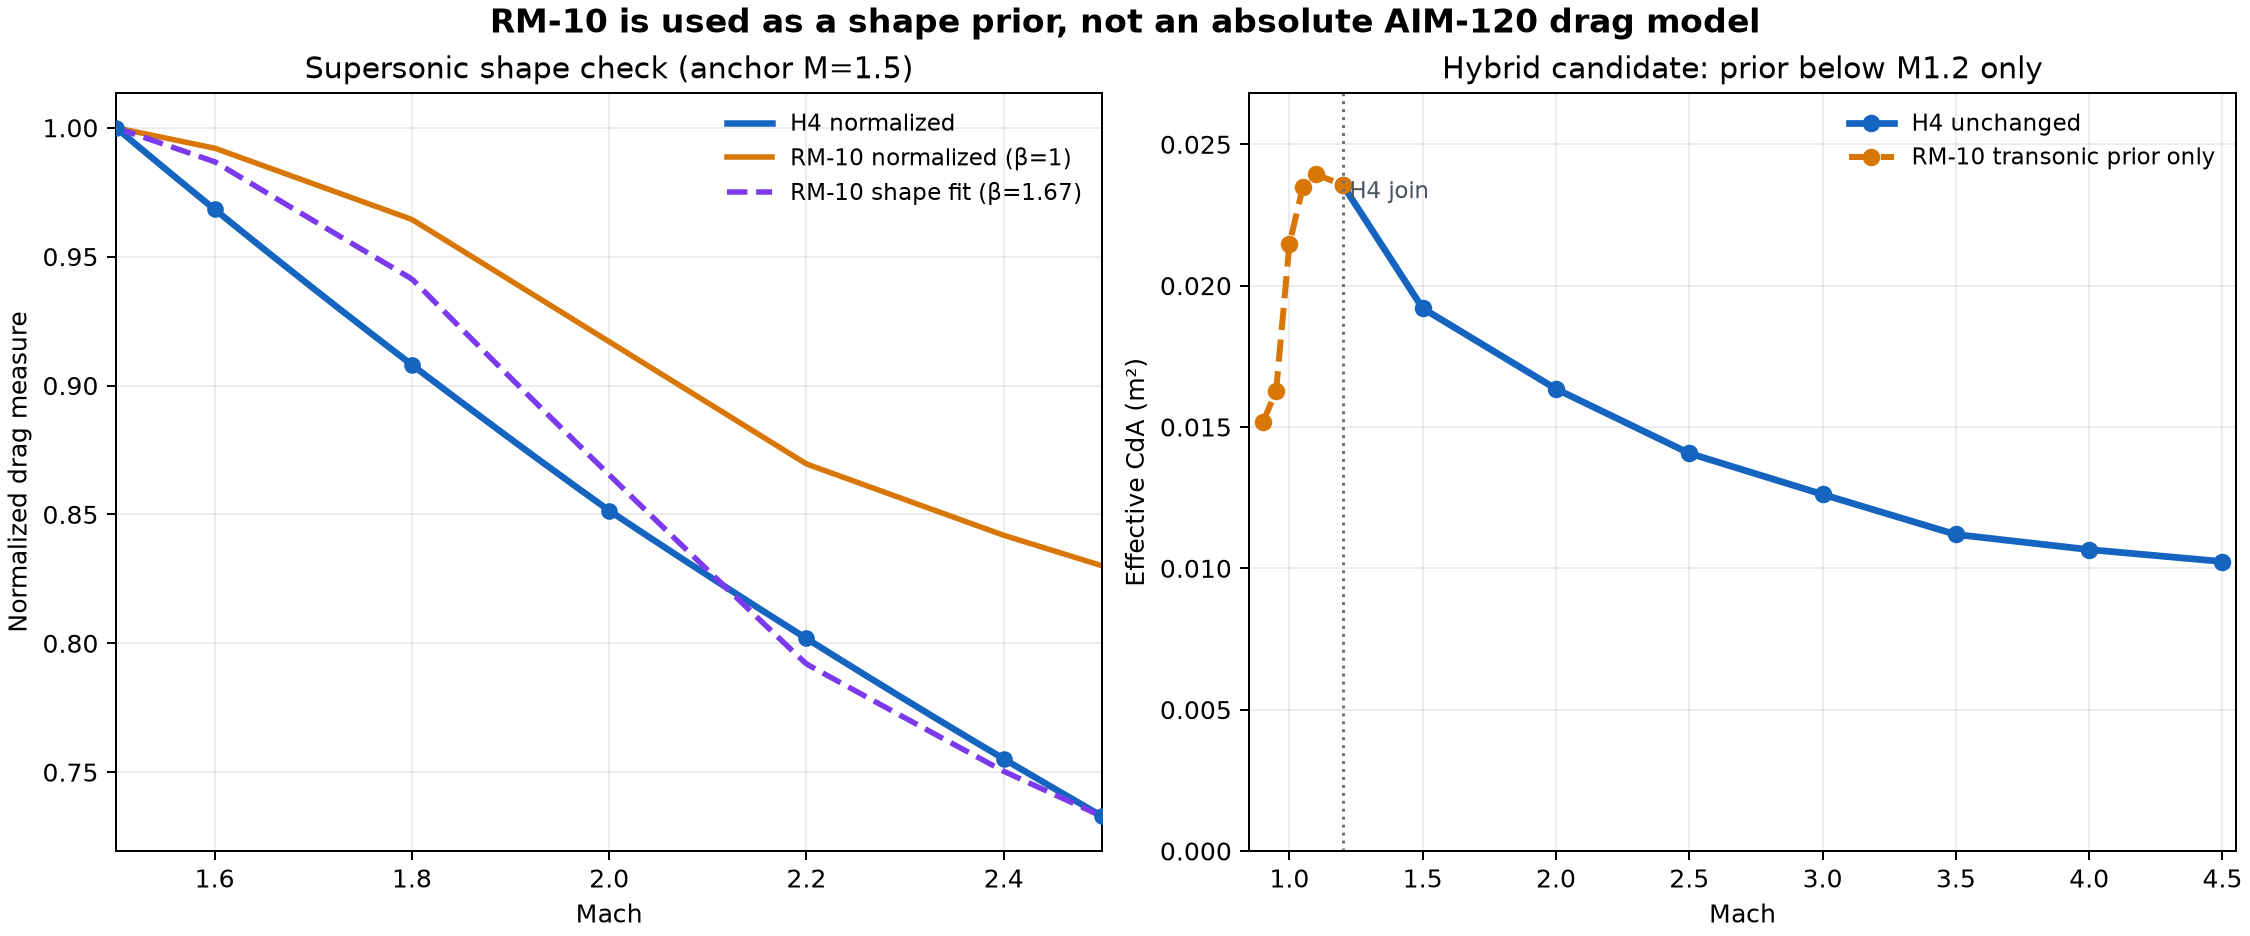

In [3]:
comparison = pd.DataFrame(fit['comparison_rows'])
display(comparison)
display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'rm10_shape_prior' / 'rm10_h4_shape_fit.png')))

## Takeaways

1. RM-10 and H4 agree qualitatively: a transonic peak is followed by declining supersonic drag.
2. They do not share the same normalized slope. The fitted `beta≈1.67` is necessary; direct constant scaling is rejected by the overlap error.
3. The practical candidate is deliberately conservative: below `M1.2`, use `CdA_H4(1.2) × Cd_RM10(M)/Cd_RM10(1.2)`; at and above `M1.2`, retain H4 unchanged.
4. `M0.9–1.2` remains prior-only and must not be labelled StatShark-identified. RM-10 contains no evidence for H4 above `M2.5`, so the existing H4 high-Mach fit is untouched.